In [63]:
import fastf1
import pandas as pd

fastf1.Cache.enable_cache('f1_cache')

years = [2022, 2023, 2024]
session_status = {}

for year in years:
    try:
        session = fastf1.get_session(year, 'Saudi Arabia', 'R')
        session.load()
        session_status[year] = "✅ Loaded"
    except Exception as e:
        session_status[year] = f"❌ Error - {str(e)}"

print(session_status)


core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 22
core        WARNING 	No lap data for driver 47
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 47)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data

{2022: '✅ Loaded', 2023: '✅ Loaded', 2024: '✅ Loaded'}


In [64]:
for year in [2022, 2023, 2024]:
    session = fastf1.get_session(year, 'Saudi Arabia', 'R')
    session.load()
    laps = session.laps

    print(f"\n📅 {year} Saudi Arabia GP:")
    print(f"Total Laps: {len(laps)}")
    print("Available Columns:", laps.columns.tolist()[:10], "...")
    print("Unique Compounds:", laps['Compound'].unique())
    print("Drivers:", laps['Driver'].unique())


core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 22
core        WARNING 	No lap data for driver 47
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 47)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data


📅 2022 Saudi Arabia GP:
Total Laps: 820
Available Columns: ['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time'] ...
Unique Compounds: ['MEDIUM' 'HARD']
Drivers: ['VER' 'GAS' 'PER' 'ALO' 'LEC' 'STR' 'MAG' 'ALB' 'ZHO' 'HUL' 'RIC' 'OCO'
 'NOR' 'HAM' 'SAI' 'LAT' 'RUS' 'BOT']


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 11 completed the race distance 00:00.035000 before the recorded end of the session.
core           INFO 	Finished loading data for 20 drivers: ['11', '1', '14', '63', '44', '55', '16', '31', '10', '20', '22', '27', '24', '21', '81', '2', '4', '77', '23', '18']
core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing


📅 2023 Saudi Arabia GP:
Total Laps: 943
Available Columns: ['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time'] ...
Unique Compounds: ['MEDIUM' 'HARD' 'SOFT']
Drivers: ['VER' 'GAS' 'PER' 'ALO' 'LEC' 'STR' 'SAR' 'MAG' 'DEV' 'TSU' 'ALB' 'ZHO'
 'HUL' 'OCO' 'NOR' 'HAM' 'SAI' 'RUS' 'BOT' 'PIA']


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '16', '81', '14', '63', '38', '4', '44', '27', '23', '20', '31', '2', '22', '3', '77', '24', '18', '10']



📅 2024 Saudi Arabia GP:
Total Laps: 901
Available Columns: ['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time'] ...
Unique Compounds: ['MEDIUM' 'HARD' 'SOFT']
Drivers: ['VER' 'GAS' 'PER' 'ALO' 'LEC' 'STR' 'SAR' 'MAG' 'TSU' 'ALB' 'ZHO' 'HUL'
 'RIC' 'OCO' 'BEA' 'NOR' 'HAM' 'RUS' 'BOT' 'PIA']


In [65]:
def process_stints(laps):
    laps = laps[(laps['LapTime'].notna()) & (laps['Compound'].notna())].copy()  # <== FIXED

    laps['LapTimeSeconds'] = laps['LapTime'].dt.total_seconds()
    laps['StintLap'] = laps.groupby(['Driver', 'Stint'])['LapNumber'].rank(method='first')
    
    return laps



In [66]:
from fastf1 import get_session

# Load and cache each year's Saudi Arabian GP race session
session_2022 = get_session(2022, 'Saudi Arabia', 'R')
session_2023 = get_session(2023, 'Saudi Arabia', 'R')
session_2024 = get_session(2024, 'Saudi Arabia', 'R')

session_2022.load()
session_2023.load()
session_2024.load()

# Extract laps
y2022 = session_2022.laps
y2023 = session_2023.laps
y2024 = session_2024.laps


core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 22
core        WARNING 	No lap data for driver 47
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 47)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data

In [67]:
laps_all_years = pd.concat([process_stints(y2022), process_stints(y2023), process_stints(y2024)])
laps_all_years.reset_index(drop=True, inplace=True)


In [68]:
# Identify pit laps from lap data (where pit time is not null)
pit_laps_2022 = y2022[y2022['PitInTime'].notna()]['LapNumber']
pit_laps_2023 = y2023[y2023['PitInTime'].notna()]['LapNumber']
pit_laps_2024 = y2024[y2024['PitInTime'].notna()]['LapNumber']

# Combine all pit laps
pit_laps = pd.concat([pit_laps_2022, pit_laps_2023, pit_laps_2024]).unique()

# Clean the data
cleaned_laps = laps_all_years[
    (laps_all_years['LapTimeSeconds'] > 80) &
    (laps_all_years['LapTimeSeconds'] < 120) &
    (~laps_all_years['LapNumber'].isin(pit_laps))
].copy()


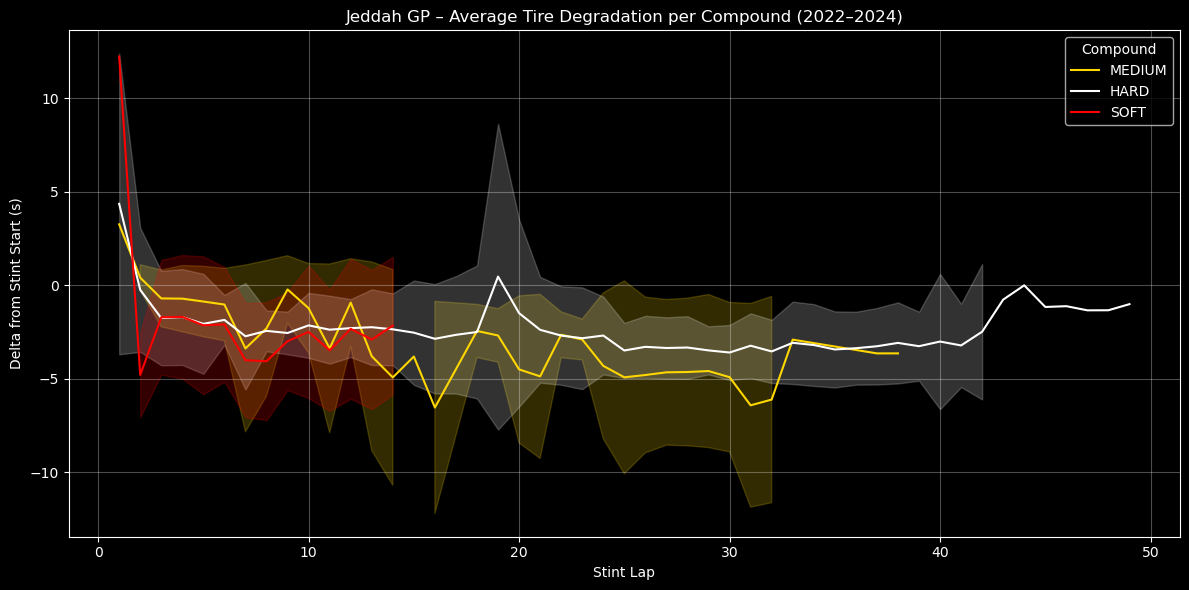

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# Normalize lap times: delta from stint start
cleaned_laps['Delta'] = cleaned_laps.groupby(['Driver', 'Stint'])['LapTimeSeconds'].transform(lambda x: x - x.iloc[0])

# Plot: Degradation by compound
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=cleaned_laps,
    x='StintLap',
    y='Delta',
    hue='Compound',
    errorbar='sd',
    palette={'SOFT': 'red', 'MEDIUM': 'gold', 'HARD': 'white'}
)
plt.title("Jeddah GP – Average Tire Degradation per Compound (2022–2024)")
plt.xlabel("Stint Lap")
plt.ylabel("Delta from Stint Start (s)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [70]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

def fit_degradation_models(laps_df, degree=2):
    models = {}
    for compound in laps_df['Compound'].unique():
        subset = laps_df[laps_df['Compound'] == compound]
        if len(subset) < 10:
            continue

        X = subset['StintLap'].values.reshape(-1, 1)
        y = subset['LapTimeSeconds'].values

        model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        model.fit(X, y)
        models[compound] = model

    return models

# Fit degradation models (e.g., 2nd-degree polynomial)
degradation_models = fit_degradation_models(cleaned_laps, degree=2)


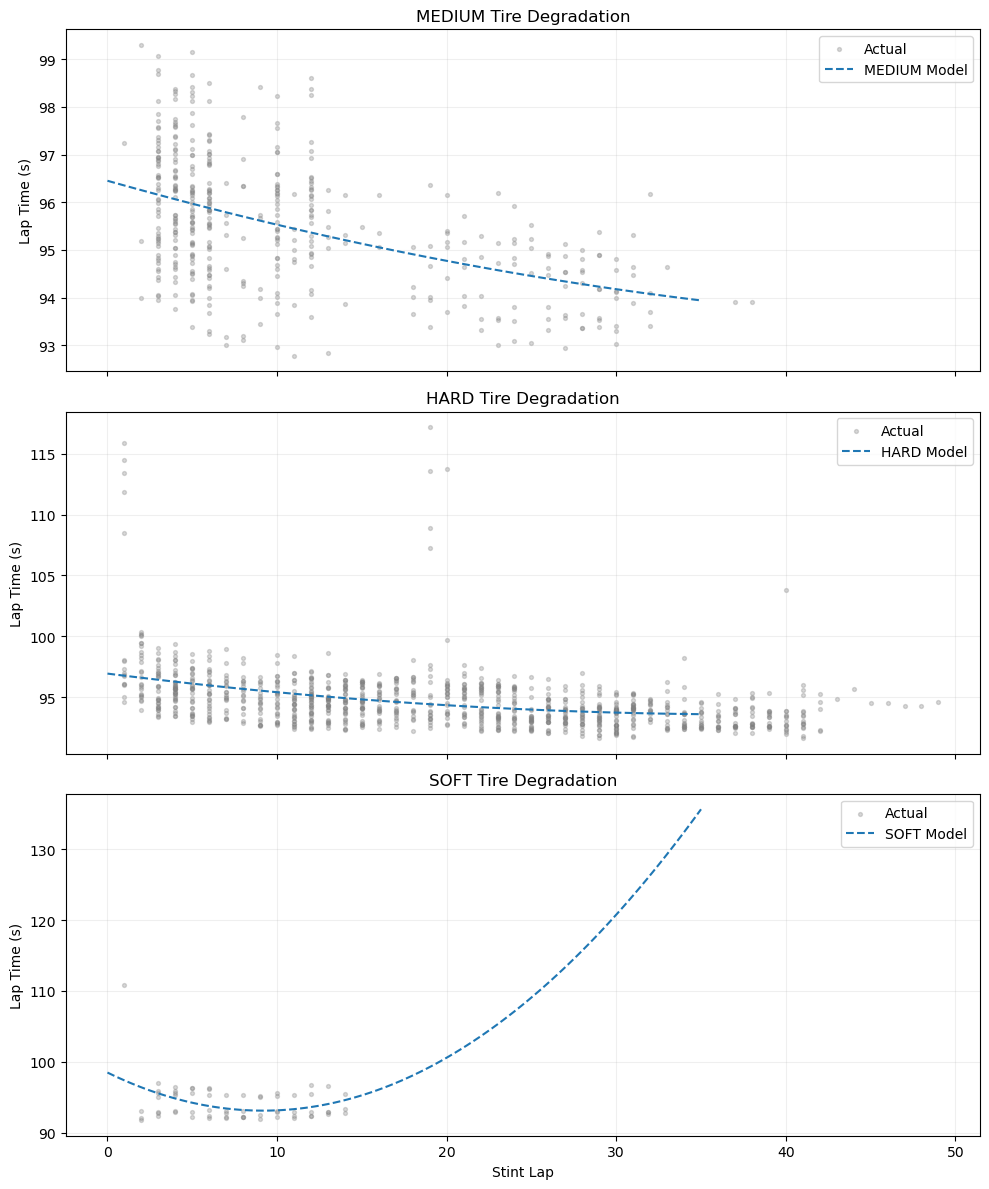

In [71]:
import matplotlib.pyplot as plt
import numpy as np

def plot_degradation_curves(laps_df, models):
    compounds = models.keys()
    plt.style.use('default')  # or just remove the line entirely
    fig, axs = plt.subplots(len(compounds), 1, figsize=(10, 4 * len(compounds)), sharex=True)

    if len(compounds) == 1:
        axs = [axs]  # ensure iterable

    for i, compound in enumerate(compounds):
        model = models[compound]
        subset = laps_df[laps_df['Compound'] == compound]

        X = subset['StintLap'].values.reshape(-1, 1)
        y = subset['LapTimeSeconds'].values

        X_pred = np.linspace(0, 35, 100).reshape(-1, 1)
        y_pred = model.predict(X_pred)

        axs[i].scatter(X, y, color='grey', s=8, alpha=0.3, label='Actual')
        axs[i].plot(X_pred, y_pred, '--', label=f'{compound} Model')
        axs[i].set_title(f"{compound} Tire Degradation", fontsize=12)
        axs[i].set_ylabel("Lap Time (s)")
        axs[i].legend()
        axs[i].grid(True, alpha=0.2)

    axs[-1].set_xlabel("Stint Lap")
    plt.tight_layout()
    plt.show()

# Plot the models
plot_degradation_curves(cleaned_laps, degradation_models)


In [72]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

def generate_degradation_models(processed_df):
    compounds = processed_df['Compound'].unique()
    deg_models = {}
    validation_metrics = {}

    plt.figure(figsize=(12, 6))

    for compound in compounds:
        data = processed_df[processed_df['Compound'] == compound]
        avg_profile = data.groupby('StintLap')['Delta'].mean().reset_index()

        if len(avg_profile) < 5:
            continue

        X = avg_profile['StintLap'].values.reshape(-1, 1)
        y = avg_profile['Delta'].values

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

        best_model, best_rmse, best_r2 = None, float('inf'), None

        for d in [2, 3, 4]:
            model = make_pipeline(PolynomialFeatures(d), LinearRegression())
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            rmse = mean_squared_error(y_test, preds, squared=False)

            if rmse < best_rmse:
                best_model = model
                best_rmse = rmse
                best_r2 = r2_score(y, best_model.predict(X))

        deg_models[compound] = best_model
        validation_metrics[compound] = {'r2': best_r2, 'rmse': best_rmse}

        X_plot = np.linspace(0, 30, 100).reshape(-1, 1)
        y_plot = best_model.predict(X_plot)

        plt.plot(X_plot, y_plot, label=f"{compound} (R²={best_r2:.2f})")
        plt.scatter(X, y, alpha=0.3)

    plt.title("Tire Degradation Models with R² Validation")
    plt.xlabel("Stint Lap")
    plt.ylabel("Δ from Baseline (s)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return deg_models, validation_metrics


In [73]:
# Establish baseline: average of first 2 laps of each stint
laps_all_years['Baseline'] = laps_all_years.groupby(['Driver', 'Stint'])['LapTimeSeconds'].transform('first')
laps_all_years['Delta'] = laps_all_years['LapTimeSeconds'] - laps_all_years['Baseline']


C:\Program Files\Anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Program Files\Anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Program Files\Anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Program Files\Anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, 

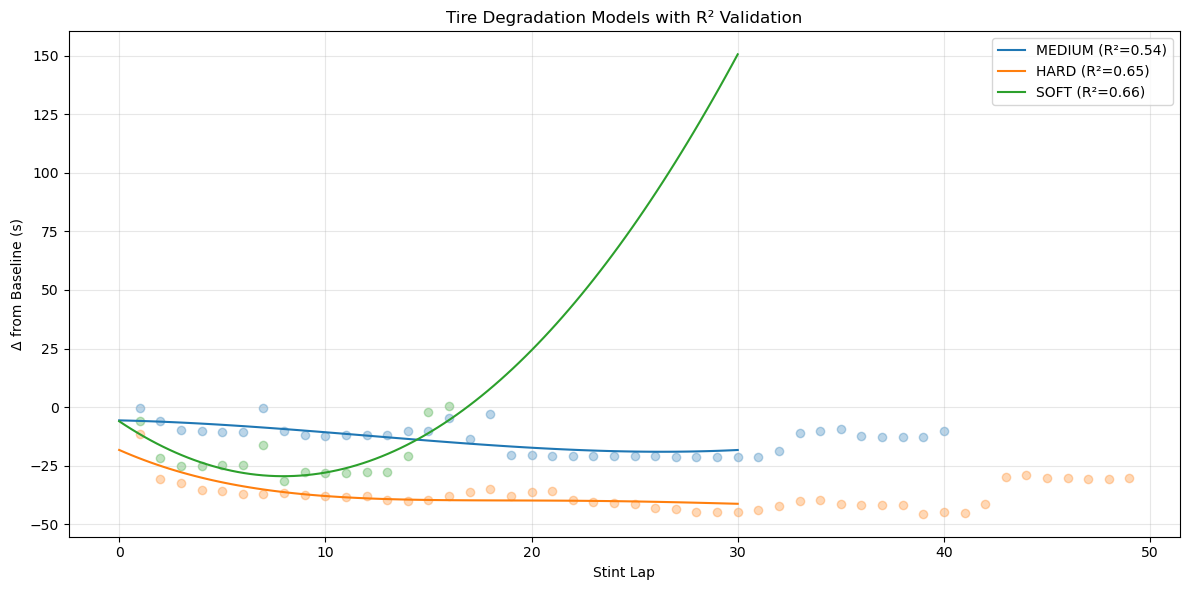

In [74]:
deg_models, metrics = generate_degradation_models(laps_all_years)


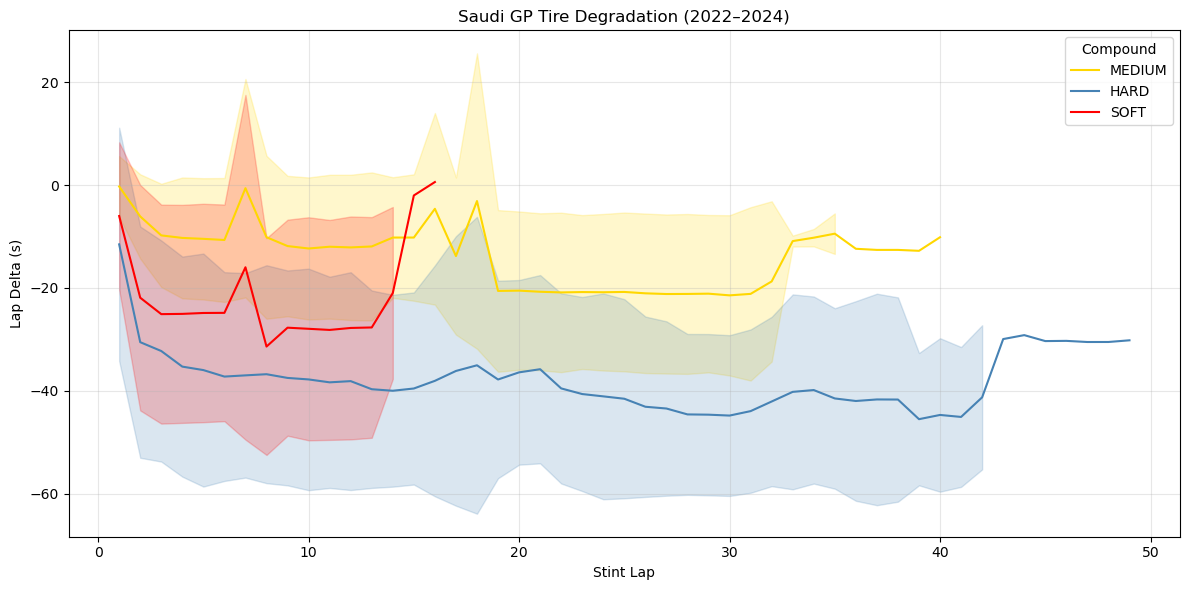

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=laps_all_years,
    x='StintLap',
    y='Delta',
    hue='Compound',
    errorbar='sd',
    palette={'SOFT': 'red', 'MEDIUM': 'gold', 'HARD': 'steelblue'}
)

plt.title("Saudi GP Tire Degradation (2022–2024)")
plt.xlabel("Stint Lap")
plt.ylabel("Lap Delta (s)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

def generate_degradation_models(processed_df):
    compounds = processed_df['Compound'].unique()
    deg_models = {}
    validation_metrics = {}

    for compound in compounds:
        data = processed_df[processed_df['Compound'] == compound].copy()
        avg_profile = data.groupby('StintLap')['Delta'].mean().reset_index()

        if len(avg_profile) < 5:
            continue

        X = avg_profile['StintLap'].values.reshape(-1, 1)
        y = avg_profile['Delta'].values

        model = make_pipeline(PolynomialFeatures(2), LinearRegression())
        model.fit(X, y)
        deg_models[compound] = model

        y_pred = model.predict(X)
        rmse = ((y - y_pred) ** 2).mean() ** 0.5
        validation_metrics[compound] = {"R2": model.score(X, y), "RMSE": rmse}

    return deg_models, validation_metrics


In [77]:
import matplotlib.pyplot as plt
import numpy as np

def plot_degradation_models(deg_models):
    plt.figure(figsize=(10, 6))
    plt.style.use('seaborn-dark')

    for compound, model in deg_models.items():
        if model is None:
            continue

        X_plot = np.linspace(1, 40, 100).reshape(-1, 1)
        y_plot = model.predict(X_plot)
        plt.plot(X_plot, y_plot, label=compound.upper())

    plt.axhline(0.75, color='white', linestyle='--', alpha=0.4)
    plt.title("Predicted Tire Degradation", fontsize=14)
    plt.xlabel("Stint Lap")
    plt.ylabel("Delta to Baseline (s)")
    plt.legend(title="Compound")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [78]:
def find_pit_thresholds(deg_models, threshold=0.75):
    pit_windows = {}

    for compound, model in deg_models.items():
        if model is None:
            pit_windows[compound] = None
            continue

        X = np.arange(1, 40).reshape(-1, 1)
        y_pred = model.predict(X)

        above_thresh = np.where(y_pred > threshold)[0]
        if len(above_thresh) > 0:
            pit_windows[compound] = X[above_thresh[0]][0]
        else:
            pit_windows[compound] = None

    return pit_windows


In [79]:
import matplotlib.pyplot as plt

def plot_pit_windows(deg_models, threshold=0.75):
    plt.style.use('dark_background')
    plt.figure(figsize=(10, 5))

    for compound, model in deg_models.items():
        if model is None:
            continue

        X = np.arange(1, 40).reshape(-1, 1)
        y_pred = model.predict(X)

        plt.plot(X, y_pred, label=compound.upper())
    
    plt.axhline(threshold, color='white', linestyle='--', alpha=0.8)
    plt.title("Pit Window Thresholds (+0.75s)", fontsize=14)
    plt.xlabel("Stint Lap")
    plt.ylabel("Delta to Baseline (s)")
    plt.grid(True, alpha=0.3)
    plt.legend(title="Compound")
    plt.tight_layout()
    plt.show()


In [80]:
from sklearn.linear_model import LinearRegression

def model_fuel_effect(processed_df):
    # Drop missing values
    fuel_data = processed_df.dropna(subset=['EstFuelLoad', 'LapTime'])

    # Fit regression: LapTime vs EstFuelLoad
    X = fuel_data['EstFuelLoad'].values.reshape(-1, 1)
    y = fuel_data['LapTime'].values
    model = LinearRegression()
    model.fit(X, y)

    coef = model.coef_[0]

    # Plot
    import matplotlib.pyplot as plt
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(X, y, alpha=0.4, label='Actual')
    ax.plot(X, model.predict(X), 'r--', label=f'Model (s/kg): {coef:.4f}')
    ax.set_title("Fuel Load Effect on Lap Time")
    ax.set_xlabel("Estimated Fuel Load (kg)")
    ax.set_ylabel("Lap Time (s)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()

    return coef, fig


In [81]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

def model_temp_sensitivity(processed_df):
    compounds = processed_df['Compound'].unique()
    colors = {
        'soft': 'red',
        'medium': 'yellow',
        'hard': 'deepskyblue'
    }

    temp_models = {}
    fig, axes = plt.subplots(len(compounds), 1, figsize=(10, 3 * len(compounds)), sharex=True)

    if len(compounds) == 1:
        axes = [axes]  # ensure iterable if only one subplot

    for i, compound in enumerate(compounds):
        compound_df = processed_df[
            (processed_df['Compound'] == compound) &
            processed_df['StintLap'].between(1, 25) &
            processed_df['TrackTemp'].notna()
        ].copy()

        if len(compound_df) < 10:
            axes[i].text(0.5, 0.5, f'Not enough data for {compound}', 
                         ha='center', va='center', transform=axes[i].transAxes)
            temp_models[compound] = None
            continue

        X = compound_df['TrackTemp'].values.reshape(-1, 1)
        y = compound_df['LapTimeSeconds'].values

        model = LinearRegression()
        model.fit(X, y)
        temp_models[compound] = model

        X_pred = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
        y_pred = model.predict(X_pred)

        axes[i].scatter(X, y, color=colors[compound.lower()], alpha=0.6, label='Actual')
        axes[i].plot(X_pred, y_pred, '--', color=colors[compound.lower()], label='Model')
        axes[i].set_title(f"{compound.upper()} Temp Sensitivity: {model.coef_[0]:.4f} s/°C")
        axes[i].set_ylabel("Lap Time (s)")
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel("Track Temperature (°C)")
    plt.tight_layout()

    return temp_models, fig



In [82]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# Define compound colors (match case!)
colors = {
    'soft': 'red',
    'medium': 'yellow',
    'hard': 'deepskyblue'
}

def model_track_evolution(processed_df):
    fig, ax = plt.subplots(figsize=(12, 6))
    compounds = processed_df['Compound'].unique()

    track_models = {}
    track_coeffs = {}

    for compound in compounds:
        compound_lower = compound.lower()
        temp_df = processed_df[
            (processed_df['Compound'] == compound) &
            processed_df['RaceProgressPct'].notna()
        ]

        X = temp_df['RaceProgressPct'].values.reshape(-1, 1)
        y = temp_df['LapTimeSeconds'].values

        if len(X) < 10:
            continue

        model = LinearRegression()
        model.fit(X, y)
        track_models[compound] = model
        track_coeffs[compound] = model.coef_[0]

        # Plot actual + predicted
        X_pred = np.linspace(0, 1, 100).reshape(-1, 1)
        y_pred = model.predict(X_pred)

        ax.scatter(X, y, color=colors[compound_lower], alpha=0.3, label=f'{compound} actual')
        ax.plot(X_pred, y_pred, color=colors[compound_lower], label=f'{compound} model')

    ax.set_title("Track Evolution Model")
    ax.set_xlabel("Race Progress (%)")
    ax.set_ylabel("Lap Time (s)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()

    return track_models, track_coeffs, fig



In [83]:
from sklearn.linear_model import LinearRegression

def model_fuel_effect(processed_df):
    early_stints = processed_df[processed_df['StintLap'] <= 15].copy()
    early_stints = early_stints.dropna(subset=['EstFuelLoad', 'LapTime'])

    if early_stints.empty:
        print("❌ Not enough early stint data for fuel model.")
        return None, None

    X = early_stints['EstFuelLoad'].values.reshape(-1, 1)
    y = early_stints['LapTime'].values

    model = LinearRegression()
    model.fit(X, y)

    fuel_coef = model.coef_[0]

    # Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(X, y, color='cyan', alpha=0.4, label='Lap Data')
    ax.plot(X, model.predict(X), color='white', linestyle='--', label=f'Fit: {fuel_coef:.3f}s/kg')
    ax.set_title("Fuel Load Effect on Lap Time")
    ax.set_xlabel("Estimated Fuel Load (kg)")
    ax.set_ylabel("Lap Time (s)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    print(f"📉 Fuel load effect: {fuel_coef:.3f} seconds per kg burned")

    return fuel_coef, fig


In [84]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

def model_team_degradation(processed_df, top_teams=None):
    if top_teams is None:
        top_teams = ['Red Bull', 'Ferrari', 'Mercedes', 'McLaren', 'Aston Martin']

    compounds = processed_df['Compound'].unique()
    team_models = {}

    fig, axes = plt.subplots(len(compounds), 1, figsize=(14, 16), sharex=True)

    for i, compound in enumerate(compounds):
        axes[i].set_title(f"{compound.upper()} Degradation by Team")

        for team in top_teams:
            df_team = processed_df[
                (processed_df['Team'] == team) &
                (processed_df['Compound'] == compound)
            ]

            if len(df_team) < 10:
                continue

            grouped = df_team.groupby('StintLap')['Delta'].mean().reset_index()

            X = grouped['StintLap'].values.reshape(-1, 1)
            y = grouped['Delta'].values

            model = make_pipeline(PolynomialFeatures(3), LinearRegression())
            model.fit(X, y)

            # Store
            if team not in team_models:
                team_models[team] = {}
            team_models[team][compound] = model

            # Plot
            X_pred = np.linspace(0, 30, 100).reshape(-1, 1)
            y_pred = model.predict(X_pred)
            axes[i].plot(X_pred, y_pred, label=team)
            axes[i].scatter(X, y, alpha=0.3, s=10)

        axes[i].set_ylabel('Delta (s)')
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()

    axes[-1].set_xlabel("Stint Lap")
    fig.tight_layout()
    return team_models, fig


In [85]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

def generate_degradation_models(processed_df):
    compounds = processed_df['Compound'].unique()
    deg_models = {}
    validation_metrics = {}

    fig, ax = plt.subplots(figsize=(12, 8))

    for compound in compounds:
        df_compound = processed_df[processed_df['Compound'] == compound]
        grouped = df_compound.groupby('StintLap')['Delta'].mean().reset_index()

        if len(grouped) < 10:
            continue

        X = grouped['StintLap'].values.reshape(-1, 1)
        y = grouped['Delta'].values

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        best_model = None
        best_rmse = float('inf')

        for deg in [2, 3, 4]:
            model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            rmse = mean_squared_error(y_test, pred, squared=False)

            if rmse < best_rmse:
                best_rmse = rmse
                best_model = model
                final_deg = deg

        # Final model on full data
        best_model.fit(X, y)
        deg_models[compound] = best_model
        full_pred = best_model.predict(X)
        r2 = r2_score(y, full_pred)

        validation_metrics[compound] = {'degree': final_deg, 'rmse': best_rmse, 'r2': r2}

        # Plot
        X_pred = np.linspace(0, 40, 200).reshape(-1, 1)
        y_pred = best_model.predict(X_pred)
        ax.plot(X_pred, y_pred, label=f'{compound} (R²: {r2:.2f})')

        ax.scatter(X, y, alpha=0.4, s=12)

    ax.set_title('Compound Degradation Curves (with Validation)')
    ax.set_xlabel('Stint Lap')
    ax.set_ylabel('Delta to Baseline (s)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    return deg_models, validation_metrics, fig


In [86]:
def simulate_race_strategy(deg_models, track_evolution, fuel_coef,
                           race_laps=50, target_team=None,
                           team_models=None, temp_adjustment=None):
    strategies = [
        {'name': 'Medium → Hard', 'compounds': ['medium', 'hard'], 'stops': [22]},
        {'name': 'Soft → Hard', 'compounds': ['soft', 'hard'], 'stops': [16]},
        {'name': 'Hard → Medium', 'compounds': ['hard', 'medium'], 'stops': [30]},
        {'name': 'Medium → Hard → Soft', 'compounds': ['medium', 'hard', 'soft'], 'stops': [18, 40]}
    ]

    if target_team and team_models and target_team in team_models:
        active_models = team_models[target_team]
    else:
        active_models = deg_models

    results = []

    for strategy in strategies:
        total_time = 0
        lap_times = []
        current_stint = 0
        compound = strategy['compounds'][0]

        for lap in range(1, race_laps + 1):
            if current_stint < len(strategy['stops']) and lap == strategy['stops'][current_stint]:
                total_time += 22.0
                current_stint += 1
                compound = strategy['compounds'][current_stint]
                stint_lap = 0
            else:
                stint_lap = lap - (strategy['stops'][current_stint - 1] if current_stint > 0 else 0) - 1

            model_lap = min(stint_lap, 30)
            baseline = 100.0

            if compound in active_models and active_models[compound]:
                delta = active_models[compound].predict([[model_lap]])[0]
            else:
                delta = 0

            fuel_effect = fuel_coef * (100 - (100 * (1 - (lap - 1) / race_laps)))
            track_gain = track_evolution.get(compound, 0) * lap / race_laps * baseline
            temp_effect = temp_adjustment.get(compound, 0) if temp_adjustment else 0

            lap_time = baseline + delta - fuel_effect - track_gain + temp_effect
            total_time += lap_time
            lap_times.append(lap_time)

        results.append({
            'strategy': strategy['name'],
            'total_time': total_time,
            'lap_times': lap_times
        })

    return results


In [87]:
import matplotlib.pyplot as plt
import numpy as np

def plot_strategy_dashboard(strategy_results):
    plt.style.use('dark_background')
    fig, axs = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})
    fig.patch.set_facecolor('#111111')
    axs[0].set_facecolor('#111111')
    axs[1].set_facecolor('#111111')

    # --- Cumulative Race Time per Lap ---
    for result in strategy_results:
        axs[0].plot(np.cumsum(result['lap_times']), label=result['strategy'], linewidth=2)

    axs[0].set_title("Cumulative Lap Time by Strategy", fontsize=14)
    axs[0].set_xlabel("Lap", fontsize=12)
    axs[0].set_ylabel("Cumulative Time (s)", fontsize=12)
    axs[0].legend()
    axs[0].grid(True, alpha=0.2)

    # --- Total Race Time Bar Chart ---
    strategies = [r['strategy'] for r in strategy_results]
    times = [r['total_time'] for r in strategy_results]
    best_idx = np.argmin(times)

    bars = axs[1].bar(strategies, times, color='gray')
    bars[best_idx].set_color('limegreen')
    axs[1].text(best_idx, times[best_idx] + 5, "Fastest", ha='center', color='limegreen', fontsize=12)
    axs[1].set_title("Total Race Time per Strategy", fontsize=14)
    axs[1].set_ylabel("Total Time (s)", fontsize=12)
    axs[1].grid(True, axis='y', alpha=0.2)

    plt.tight_layout()
    plt.show()


In [88]:
# Step 1: Process stint data
laps_all_years = pd.concat([
    process_stints(y2022),
    process_stints(y2023),
    process_stints(y2024)
])

# Step 2: Clean index
laps_all_years.reset_index(drop=True, inplace=True)

# Step 3: Add normalized race progress column
laps_all_years['RaceProgressPct'] = laps_all_years['LapNumber'] / laps_all_years['LapNumber'].max()



In [89]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pit_window_thresholds(deg_models, threshold=0.75):
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(10, 5))

    for compound, model in deg_models.items():
        if model is None:
            continue
        x_vals = np.linspace(1, 40, 200).reshape(-1, 1)
        y_vals = model.predict(x_vals)

        ax.plot(x_vals, y_vals, label=compound.upper())
        
        # Highlight the threshold crossing point
        cross_idx = np.argmax(y_vals > threshold)
        if y_vals[cross_idx] > threshold:
            ax.axvline(x=x_vals[cross_idx][0], color='white', linestyle='--', alpha=0.5)

    ax.axhline(threshold, color='white', linestyle='--', alpha=0.8)
    ax.set_title("Pit Window Thresholds (+0.75s)", fontsize=14)
    ax.set_xlabel("Stint Lap")
    ax.set_ylabel("Delta to Baseline (s)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



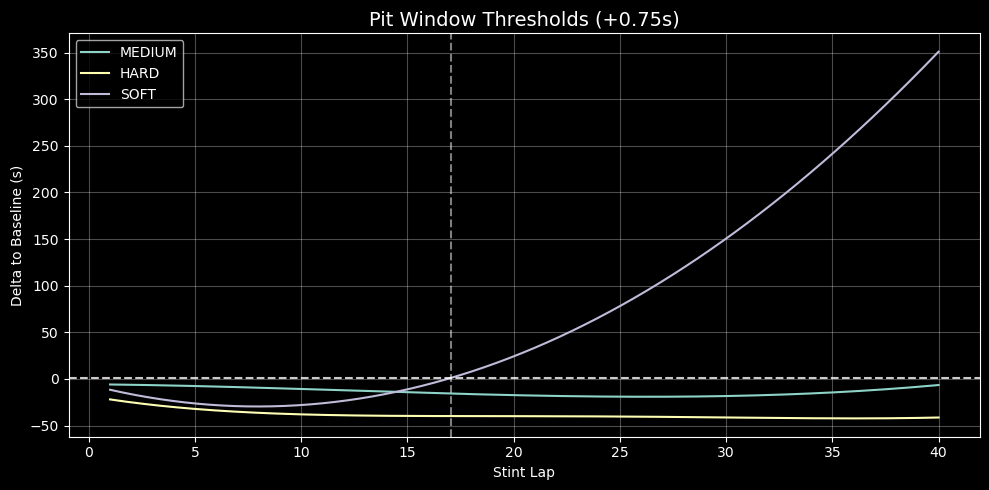

In [90]:
plot_pit_window_thresholds(deg_models)


In [91]:
def extract_pit_thresholds(deg_models, threshold=0.75):
    stint_thresholds = {}

    for compound, model in deg_models.items():
        if model is None:
            continue
        x_vals = np.arange(1, 41).reshape(-1, 1)
        y_vals = model.predict(x_vals)

        # Find the first stint lap where delta exceeds the threshold
        above_thresh = np.where(y_vals > threshold)[0]
        if len(above_thresh) > 0:
            stint_thresholds[compound.upper()] = int(x_vals[above_thresh[0]][0])
        else:
            stint_thresholds[compound.upper()] = None  # Never crosses threshold

    return stint_thresholds

# Run the function
stint_limits = extract_pit_thresholds(deg_models)
stint_limits


{'MEDIUM': None, 'HARD': None, 'SOFT': 17}

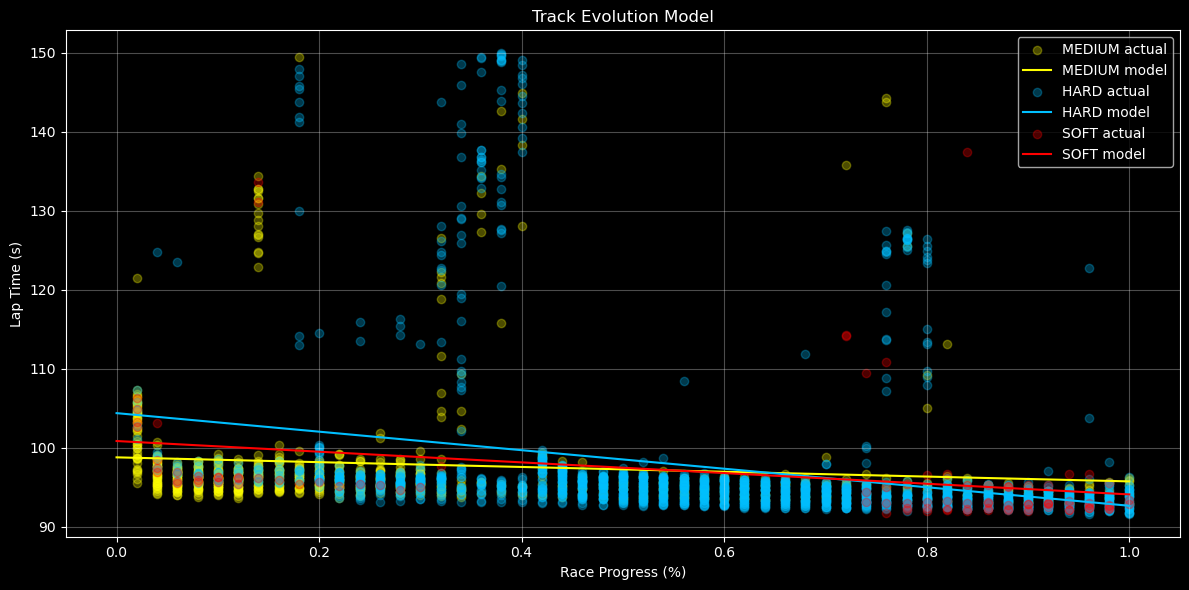

In [92]:
# Assuming this exists already in your notebook
track_models, track_coeffs, _ = model_track_evolution(laps_all_years)


In [93]:
# Estimate fuel load per lap using simple linear decay
laps_all_years['EstFuelLoad'] = 110 - (laps_all_years['LapNumber'] * (110 / 50))  # Assuming 110kg start, 50 lap race



In [94]:
laps_all_years['LapTimeSeconds'] = laps_all_years['LapTime'].dt.total_seconds()



In [95]:
early_stints = laps_all_years[laps_all_years['StintLap'] <= 15].copy()
early_stints = early_stints.dropna(subset=['EstFuelLoad', 'LapTimeSeconds'])

X = early_stints['EstFuelLoad'].values.reshape(-1, 1)
y = early_stints['LapTimeSeconds'].values


In [96]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def model_fuel_effect(processed_df):
    early_stints = processed_df[processed_df['StintLap'] <= 15].copy()

    # Estimate fuel load (110kg start assumed)
    early_stints['EstFuelLoad'] = 110 - (early_stints['LapNumber'] * (110 / 50))
    early_stints = early_stints.dropna(subset=['EstFuelLoad', 'LapTimeSeconds'])

    if early_stints.empty:
        print("❌ Not enough early stint data for fuel model.")
        return None, None

    X = early_stints['EstFuelLoad'].values.reshape(-1, 1)
    y = early_stints['LapTimeSeconds'].values

    model = LinearRegression()
    model.fit(X, y)
    fuel_coef = model.coef_[0]

    # Optional Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(X, y, color='cyan', alpha=0.4, label='Actual')
    ax.plot(X, model.predict(X), color='white', linestyle='--',
            label=f"Model: {fuel_coef:.3f} s/kg")
    ax.set_title("Fuel Load Effect on Lap Time")
    ax.set_xlabel("Estimated Fuel Load (kg)")
    ax.set_ylabel("Lap Time (s)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    
    print(f"📉 Fuel load effect: {fuel_coef:.3f} seconds per kg burned")

    return fuel_coef, fig


📉 Fuel load effect: 0.040 seconds per kg burned


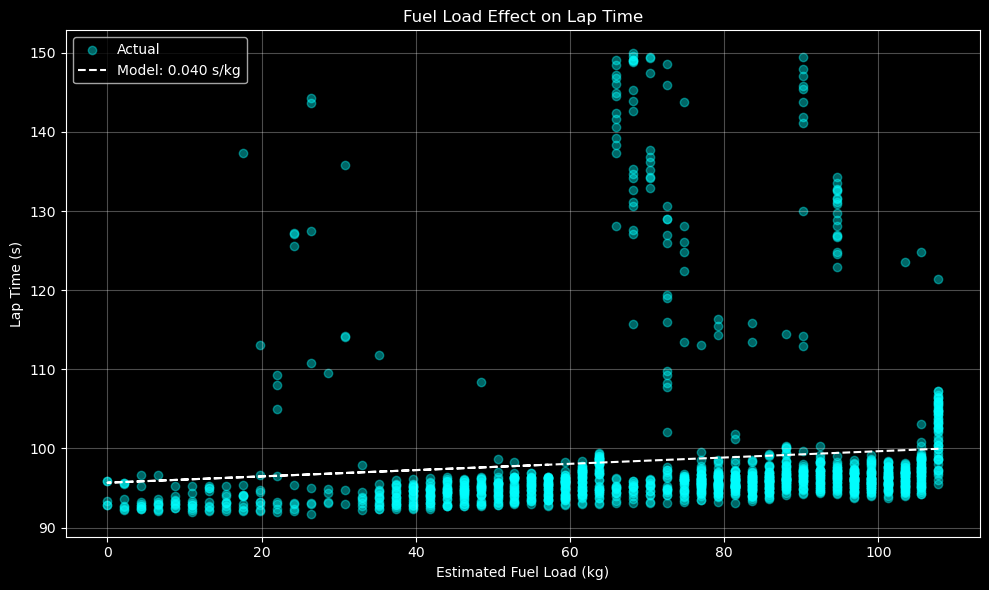

In [97]:
fuel_coef, _ = model_fuel_effect(laps_all_years)


In [98]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

def model_temp_sensitivity(processed_df):
    compounds = processed_df['Compound'].unique()
    colors = {
        'soft': 'red',
        'medium': 'yellow',
        'hard': 'deepskyblue'
    }

    temp_models = {}
    fig, axes = plt.subplots(len(compounds), 1, figsize=(10, 3 * len(compounds)), sharex=True)

    if len(compounds) == 1:
        axes = [axes]

    for i, compound in enumerate(compounds):
        compound_df = processed_df[
            (processed_df['Compound'] == compound) &
            (processed_df['StintLap'].between(1, 25)) &
            (processed_df['TrackTemp'].notna())
        ].copy()

        if len(compound_df) < 10:
            axes[i].text(0.5, 0.5, f'Not enough data for {compound}', 
                         ha='center', va='center', transform=axes[i].transAxes)
            temp_models[compound] = None
            continue

        X = compound_df['TrackTemp'].values.reshape(-1, 1)
        y = compound_df['LapTimeSeconds'].values

        model = LinearRegression()
        model.fit(X, y)
        temp_models[compound] = model

        X_pred = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
        y_pred = model.predict(X_pred)

        axes[i].scatter(X, y, color=colors[compound.lower()], alpha=0.6, label='Actual')
        axes[i].plot(X_pred, y_pred, color=colors[compound.lower()], label='Model')
        axes[i].set_title(f"{compound.upper()} Temp Sensitivity: {model.coef_[0]:.4f} s/°C")
        axes[i].set_ylabel("Lap Time (s)")
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel("Track Temperature (°C)")
    plt.tight_layout()
    return temp_models, fig


In [99]:
laps_all_years['Compound'].unique()


array(['MEDIUM', 'HARD', 'SOFT'], dtype=object)

In [100]:
print(laps_all_years.columns.tolist())


['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate', 'LapTimeSeconds', 'StintLap', 'RaceProgressPct', 'EstFuelLoad']


In [101]:
laps_all_years.rename(columns={'ActualName': 'TrackTemp'}, inplace=True)


In [102]:
import numpy as np

def simulate_safety_car_events(num_laps=50, sc_probability=0.1, seed=42):
    np.random.seed(seed)
    return np.random.rand(num_laps) < sc_probability  # Boolean array per lap

# Example: simulate for Jeddah 50-lap race
safety_car_laps = simulate_safety_car_events(num_laps=50, sc_probability=0.12)
print("Laps with Safety Car:", np.where(safety_car_laps)[0].tolist())


Laps with Safety Car: [6, 10, 29, 32, 37, 42]


In [103]:
def simulate_race_strategy_with_safetycar(
    deg_models, track_evolution, fuel_coef,
    safety_car_laps,  # <--- Boolean array of len race_laps
    race_laps=50, target_team=None,
    team_models=None, temp_adjustment=None
):
    import matplotlib.pyplot as plt
    import numpy as np

    strategies = [
        {'name': 'Medium -> Hard', 'compounds': ['medium', 'hard'], 'stops': [22]},
        {'name': 'Soft -> Hard', 'compounds': ['soft', 'hard'], 'stops': [16]},
        {'name': 'Hard -> Medium', 'compounds': ['hard', 'medium'], 'stops': [30]},
        {'name': 'Medium -> Hard -> Soft', 'compounds': ['medium', 'hard', 'soft'], 'stops': [18, 40]}
    ]

    active_models = team_models[target_team] if target_team and team_models and target_team in team_models else deg_models
    strategy_results = []

    for strategy in strategies:
        total_time, lap_times, compounds_used = 0, [], []
        current_stint = 0
        current_compound = strategy['compounds'][current_stint]

        for lap in range(1, race_laps + 1):
            is_safety_car = safety_car_laps[lap - 1]

            if current_stint < len(strategy['stops']) and lap == strategy['stops'][current_stint]:
                pit_loss = 12.0 if is_safety_car else 22.0  # Less time loss under SC
                total_time += pit_loss
                current_stint += 1
                current_compound = strategy['compounds'][current_stint]
                stint_lap = 0
            else:
                stint_lap = lap - 1 if current_stint == 0 else lap - strategy['stops'][current_stint - 1] - 1

            model_stint_lap = min(stint_lap, 30)
            baseline = 100.0
            delta = active_models.get(current_compound).predict([[model_stint_lap]])[0] if current_compound in active_models else 0
            fuel_effect = fuel_coef * (100 - (100 * (lap - 1) / race_laps))
            track_gain = track_evolution.get(current_compound, 0) * lap / race_laps * baseline
            temp_effect = temp_adjustment.get(current_compound, 0) if temp_adjustment else 0

            # Apply Safety Car effect
            safety_car_penalty = np.random.uniform(12, 18) if is_safety_car else 0
            lap_time = baseline + delta - fuel_effect - track_gain + temp_effect + safety_car_penalty

            total_time += lap_time
            lap_times.append(lap_time)
            compounds_used.append(current_compound)

        strategy_results.append({
            'strategy': strategy['name'],
            'total_time': total_time,
            'lap_times': lap_times,
            'compounds': compounds_used
        })

    return strategy_results


In [104]:
import numpy as np

# 👇 Create a hypothetical SC scenario (Jeddah is ~50 laps)
# Assume SC active on laps 12–14 and 35–36
race_laps = 50
safety_car_laps = np.zeros(race_laps, dtype=bool)
safety_car_laps[11:14] = True  # Laps 12-14
safety_car_laps[34:36] = True  # Laps 35-36


In [105]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

def generate_degradation_models(processed_df):
    import matplotlib.pyplot as plt
    import numpy as np

    compounds = processed_df['Compound'].unique()
    deg_models = {}
    validation_metrics = {}

    fig, ax = plt.subplots(figsize=(12, 8))

    for compound in compounds:
        compound_data = processed_df[processed_df['Compound'] == compound].copy()
        stint_profile = compound_data.groupby('StintLap')['Delta'].mean().reset_index()

        if len(stint_profile) >= 10:
            X = stint_profile['StintLap'].values.reshape(-1, 1)
            y = stint_profile['Delta'].values

            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

            best_rmse = float('inf')
            best_degree = 3

            for degree in [2, 3, 4]:
                model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                rmse = np.sqrt(mean_squared_error(y_test, y_pred))

                if rmse < best_rmse:
                    best_rmse = rmse
                    best_degree = degree

            final_model = make_pipeline(PolynomialFeatures(best_degree), LinearRegression())
            final_model.fit(X, y)

            y_pred_full = final_model.predict(X)
            r2 = r2_score(y, y_pred_full)
            rmse = np.sqrt(mean_squared_error(y, y_pred_full))

            deg_models[compound] = final_model
            validation_metrics[compound] = {'degree': best_degree, 'r2': r2, 'rmse': rmse}

            X_pred = np.linspace(0, 40, 200).reshape(-1, 1)
            y_pred = final_model.predict(X_pred)

            ax.plot(X_pred, y_pred, label=f'{compound} (R²: {r2:.3f})')
            ax.scatter(X, y, alpha=0.5, s=10)

    ax.set_title('Tire Degradation Curves with Validation')
    ax.set_xlabel('Stint Lap')
    ax.set_ylabel('Delta to Baseline (s)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    return deg_models, validation_metrics, fig


In [106]:
def process_stints(laps_df):
    processed_data = []

    # Group by Driver, Year, and Stint
    grouped = laps_df.groupby(['Driver', 'Year', 'Stint'])

    for (driver, year, stint), group in grouped:
        if len(group) < 3:
            continue

        group = group.sort_values('LapNumber')
        compound = group['Compound'].iloc[0].lower()
        if compound not in ['soft', 'medium', 'hard']:
            continue

        baseline_lap = group.iloc[1]['LapTime'].total_seconds()
        team = group['Team'].iloc[0]

        for i, (_, lap) in enumerate(group.iterrows()):
            lap_time = lap['LapTime'].total_seconds()
            if lap_time > baseline_lap * 1.1:
                continue

            processed_data.append({
                'Driver': driver,
                'Team': team,
                'Year': year,
                'Compound': compound,
                'Stint': stint,
                'LapNumber': lap['LapNumber'],
                'StintLap': i,
                'LapTime': lap_time,
                'Delta': lap_time - baseline_lap,
                'TrackTemp': lap.get('TrackTemp', None),
                'AirTemp': lap.get('AirTemp', None),
                'EstFuelLoad': 100 - (lap['LapNumber'] * 1.5)
            })

    return pd.DataFrame(processed_data)


In [107]:
from fastf1 import get_session

In [108]:
session_2022 = get_session(2022, 'Saudi Arabia', 'R')
session_2023 = get_session(2023, 'Saudi Arabia', 'R')
session_2024 = get_session(2024, 'Saudi Arabia', 'R')

session_2022.load()
session_2023.load()
session_2024.load()


core           INFO 	Loading data for Saudi Arabian Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 22
core        WARNING 	No lap data for driver 47
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 22)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 47)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data

In [109]:
y2022 = session_2022.laps
y2022023 = session_2023.laps
y2024 = session_2024.laps

In [110]:
def calculate_traffic_exposure(laps_df):
    laps_with_traffic = laps_df.copy()
    laps_with_traffic['TrafficCount'] = 0

    for lap_number in laps_df['LapNumber'].unique():
        lap_slice = laps_df[laps_df['LapNumber'] == lap_number]
        deltas = lap_slice['LapTimeSeconds'].values

        traffic = []
        for i, delta in enumerate(deltas):
            count = ((abs(deltas - delta) <= 2.0) & (abs(deltas - delta) > 0)).sum()
            traffic.append(count)

        laps_with_traffic.loc[laps_with_traffic['LapNumber'] == lap_number, 'TrafficCount'] = traffic

    return laps_with_traffic


In [111]:
laps_all_years = calculate_traffic_exposure(laps_all_years)
